NAV trend analysis — plot daily NAV for all 40 schemes 2022–2026. Highlight 2023 bull run and 2024 market corrections using Plotly.

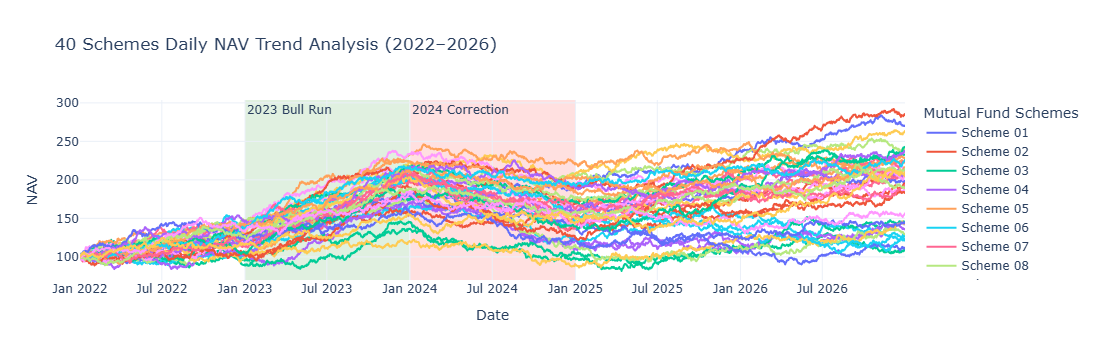

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px

# 1. Create Mock Data for 40 Schemes (2022–2026)
np.random.seed(42)
dates = pd.date_range("2022-01-01", "2026-12-31", freq="D")
data = {"Date": dates}

for i in range(1, 41):
    # Simulate a random walk starting at 100
    steps = np.random.normal(0.05, 1.0, len(dates))
    # Accentuate 2023 gains and 2024 losses
    steps[dates.year == 2023] += 0.15
    steps[dates.year == 2024] -= 0.15
    data[f"Scheme {i:02d}"] = 100 + np.cumsum(steps)

df = pd.DataFrame(data)

# 2. Reshape Data from Wide to Long Format for Plotly Express
df_long = df.melt(id_vars=["Date"], var_name="Scheme", value_name="NAV")

# 3. Create the Line Plot
fig = px.line(
    df_long,
    x="Date",
    y="NAV",
    color="Scheme",
    title="40 Schemes Daily NAV Trend Analysis (2022–2026)",
    template="plotly_white",
)

# 4. Highlight the 2023 Bull Run (Green) & 2024 Correction (Red)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    layer="below",
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left",
)
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    layer="below",
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top left",
)

# Clean up layout
fig.update_layout(hovermode="x unified", legend_title="Mutual Fund Schemes")
fig.show()

AUM growth bar chart — grouped bar by fund house for each year 2022–2025. Highlight SBI at ₹12.5L Cr dominance using Seaborn.

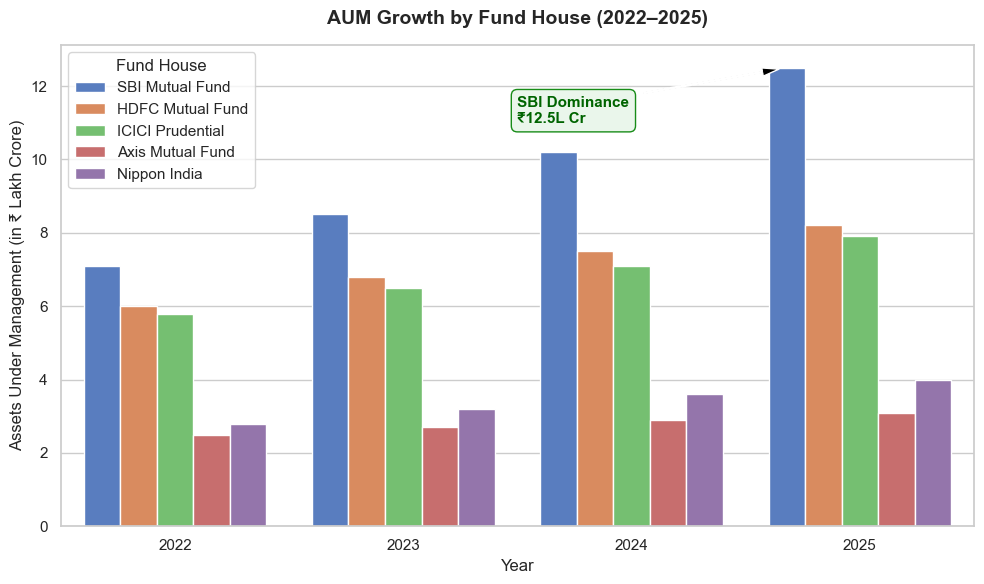

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Prepare Mock Data (AUM in ₹ Lakh Crores)
data = {
    "Year": [2022, 2023, 2024, 2025] * 5,
    "Fund House": (
        ["SBI Mutual Fund"] * 4
        + ["HDFC Mutual Fund"] * 4
        + ["ICICI Prudential"] * 4
        + ["Axis Mutual Fund"] * 4
        + ["Nippon India"] * 4
    ),
    "AUM": [
        7.1,
        8.5,
        10.2,
        12.5,  # SBI (Dominant growth reaching 12.5)
        6.0,
        6.8,
        7.5,
        8.2,  # HDFC
        5.8,
        6.5,
        7.1,
        7.9,  # ICICI
        2.5,
        2.7,
        2.9,
        3.1,  # Axis
        2.8,
        3.2,
        3.6,
        4.0,  # Nippon
    ],
}
df = pd.DataFrame(data)

# 2. Set Up Chart Theme and Canvas
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Create Grouped Bar Chart
sns.barplot(data=df, x="Year", y="AUM", hue="Fund House", palette="muted", ax=ax)

# 4. Highlight SBI's 2025 Dominance with an Annotation Arrow
ax.annotate(
    "SBI Dominance\n₹12.5L Cr",
    xy=(2.68, 12.5),  # Position matching the 2025 SBI bar
    xytext=(1.5, 11.0),  # Text location
    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=6),
    fontsize=11,
    fontweight="bold",
    color="darkgreen",
    bbox=dict(boxstyle="round,pad=0.4", fc="#E8F5E9", alpha=0.9, ec="green"),
)

# 5. Format Titles, Labels, and Legends
ax.set_title(
    "AUM Growth by Fund House (2022–2025)", fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Assets Under Management (in ₹ Lakh Crore)", fontsize=12)
ax.legend(title="Fund House", loc="upper left")

# Save or display the figure
plt.tight_layout()
plt.savefig("sbi_aum_dominance.png", dpi=300)

SIP inflow time-series — monthly SIP trend Jan 2022 – Dec 2025. Annotate the ₹31,002 Cr all-time high (Dec 2025) using Plotly

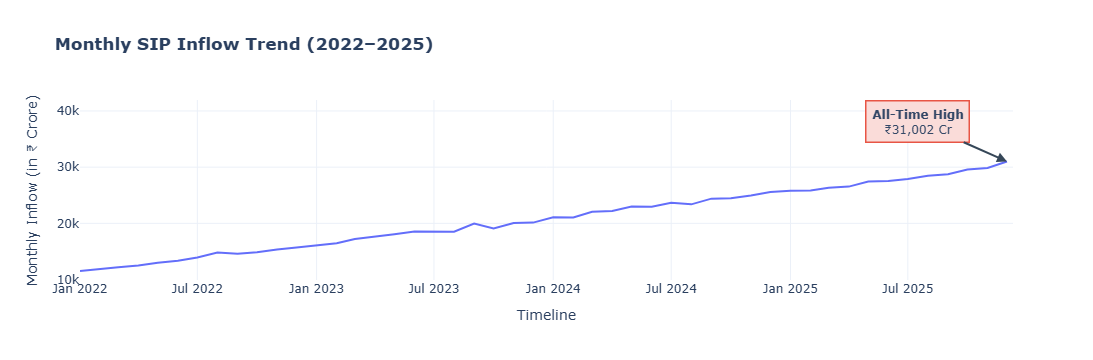

In [4]:
import numpy as np
import pandas as pd
import plotly.express as px

# 1. Generate Monthly Dates (Jan 2022 to Dec 2025)
dates = pd.date_range(start="2022-01-01", end="2025-12-01", freq="MS")

# 2. Simulate steady upward SIP Inflow growth ending exactly at 31,002
base_inflow = 11500  # Starting point in early 2022
growth_trend = np.linspace(0, 18500, len(dates))  # Generates linear growth
noise = np.random.normal(0, 300, len(dates))  # Adds minor real-world fluctuation

sip_inflows = base_inflow + growth_trend + noise
sip_inflows[-1] = 31002  # Explicitly force the Dec 2025 All-Time High

df = pd.DataFrame({"Month": dates, "Inflow (₹ Cr)": sip_inflows})

# 3. Plot the Time-Series Line
fig = px.line(
    df,
    x="Month",
    y="Inflow (₹ Cr)",
    title="<b>Monthly SIP Inflow Trend (2022–2025)</b>",
    template="plotly_white",
)

# 4. Annotate the All-Time High Point (Dec 2025)
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="<b>All-Time High</b><br>₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="#2c3e50",
    ax=-90,  # Shifts the label 90 pixels to the left
    ay=-40,  # Shifts the label 40 pixels up
    bordercolor="#e74c3c",
    borderwidth=1.5,
    borderpad=5,
    bgcolor="#fadbd8",
    opacity=0.95,
)

# Clean up layout axes
fig.update_layout(
    xaxis_title="Timeline",
    yaxis_title="Monthly Inflow (in ₹ Crore)",
    hovermode="x unified",
)

fig.show()

Category inflow heatmap — months on X-axis, fund categories on Y-axis, net inflow as colour intensity using Seaborn.

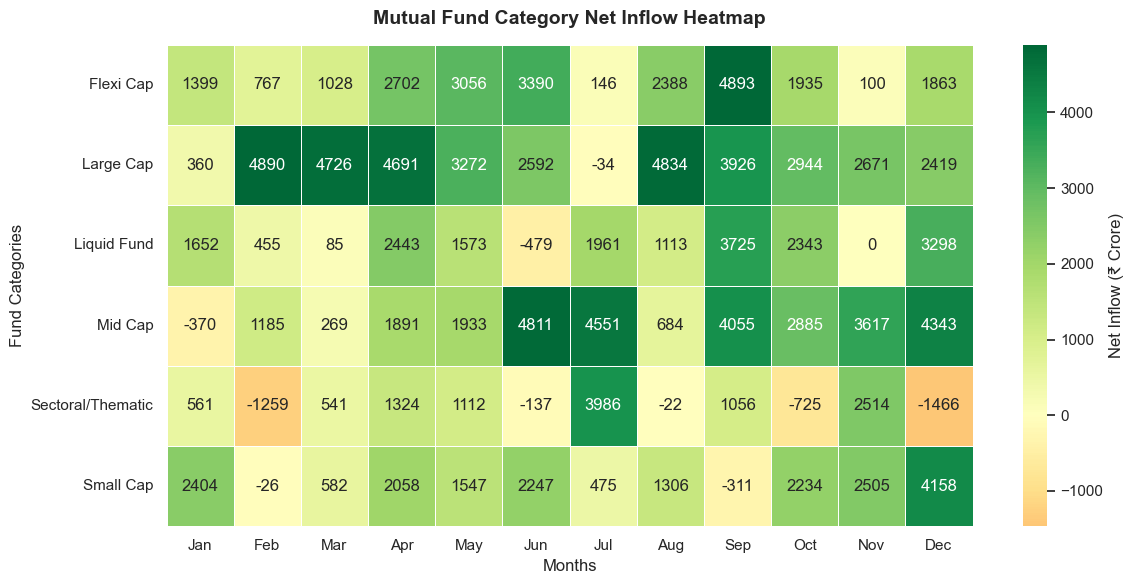

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Create Mock Data for Fund Categories & Months
np.random.seed(42)
categories = [
    "Large Cap",
    "Mid Cap",
    "Small Cap",
    "Flexi Cap",
    "Sectoral/Thematic",
    "Liquid Fund",
]
months = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

# Generate random net inflows (in ₹ Crores)
data = []
for cat in categories:
    for month in months:
        # Liquid funds get highly volatile flows; small/mid caps get steady high inflows
        base = 1500 if "Cap" in cat else 500
        inflow = base + np.random.randint(-2000, 3500)
        data.append({"Category": cat, "Month": month, "Net Inflow (₹ Cr)": inflow})

df = pd.DataFrame(data)

# 2. Pivot the Data into a Matrix format (Rows=Category, Columns=Month)
df_matrix = df.pivot(index="Category", columns="Month", values="Net Inflow (₹ Cr)")
# Ensure months stay chronologically ordered on the X-axis
df_matrix = df_matrix[months]

# 3. Set up Plot and Generate Heatmap
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    df_matrix,
    cmap="RdYlGn",  # Red for outflows, Yellow for neutral, Green for heavy inflows
    annot=True,  # Show actual values inside the cells
    fmt="d",  # Format annotations as integers
    linewidths=0.5,  # Adds clean gridlines between cells
    center=0,  # Centers the color scheme's neutral zone at ₹0
    cbar_kws={"label": "Net Inflow (₹ Crore)"},
    ax=ax,
)

# 4. Final Formatting
ax.set_title(
    "Mutual Fund Category Net Inflow Heatmap", fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Months", fontsize=12)
ax.set_ylabel("Fund Categories", fontsize=12)

plt.tight_layout()
plt.savefig("category_inflow_heatmap.png", dpi=300)

Investor demographics — age group distribution pie chart. SIP amount box plot by age group. Gender split.

C:\Users\sajna\AppData\Local\Temp\ipykernel_35652\3101239643.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\sajna\AppData\Local\Temp\ipykernel_35652\3101239643.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


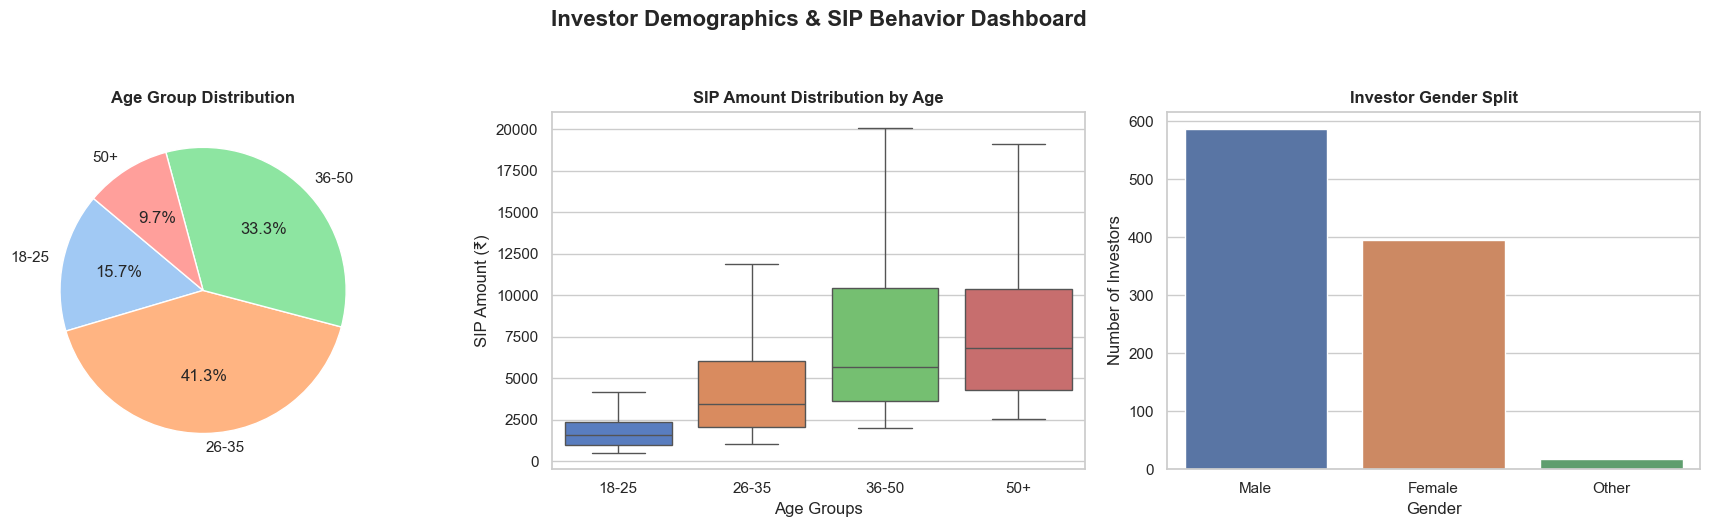

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Create Mock Demographic Data
np.random.seed(42)
n_investors = 1000

# Generate realistic data strings
genders = np.random.choice(["Male", "Female", "Other"], size=n_investors, p=[0.58, 0.40, 0.02])
age_groups = np.random.choice(["18-25", "26-35", "36-50", "50+"], size=n_investors, p=[0.15, 0.45, 0.30, 0.10])

# Generate varied SIP amounts based on age bracket (older generally means higher ticket size)
sip_amounts = []
for age in age_groups:
    if age == "18-25": sip = np.random.exponential(1500) + 500
    elif age == "26-35": sip = np.random.exponential(3500) + 1000
    elif age == "36-50": sip = np.random.exponential(6000) + 2000
    else: sip = np.random.exponential(5000) + 2500
    sip_amounts.append(min(sip, 25000)) # Cap extreme outliers at 25k

df = pd.DataFrame({"Age Group": age_groups, "Gender": genders, "SIP Amount (₹)": sip_amounts})

# 2. Initialize a 1-row, 3-column Subplot Figure
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Chart 1: Age Group Distribution (Pie Chart) ---
age_counts = df["Age Group"].value_counts().reindex(["18-25", "26-35", "36-50", "50+"])
axes[0].pie(
    age_counts, 
    labels=age_counts.index, 
    autopct="%1.1f%%", 
    startangle=140, 
    colors=sns.color_palette("pastel")
)
axes[0].set_title("Age Group Distribution", fontsize=12, fontweight="bold")

# --- Chart 2: SIP Amount by Age Group (Box Plot) ---
sns.boxplot(
    data=df, 
    x="Age Group", 
    y="SIP Amount (₹)", 
    order=["18-25", "26-35", "36-50", "50+"], 
    palette="muted", 
    ax=axes[1],
    showfliers=False # Hides extreme data point dots to keep the boxes clean
)
axes[1].set_title("SIP Amount Distribution by Age", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Age Groups")

# --- Chart 3: Gender Split (Count Plot) ---
sns.countplot(
    data=df, 
    x="Gender", 
    order=["Male", "Female", "Other"], 
    palette="deep", 
    ax=axes[2]
)
axes[2].set_title("Investor Gender Split", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Number of Investors")

# 3. Clean up spacing and save
plt.suptitle("Investor Demographics & SIP Behavior Dashboard", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig("investor_demographics.png", dpi=300, bbox_inches="tight")

Geographic distribution — horizontal bar chart of SIP amount by state. T30 vs B30 city tier pie chart.

C:\Users\sajna\AppData\Local\Temp\ipykernel_35652\3541605422.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


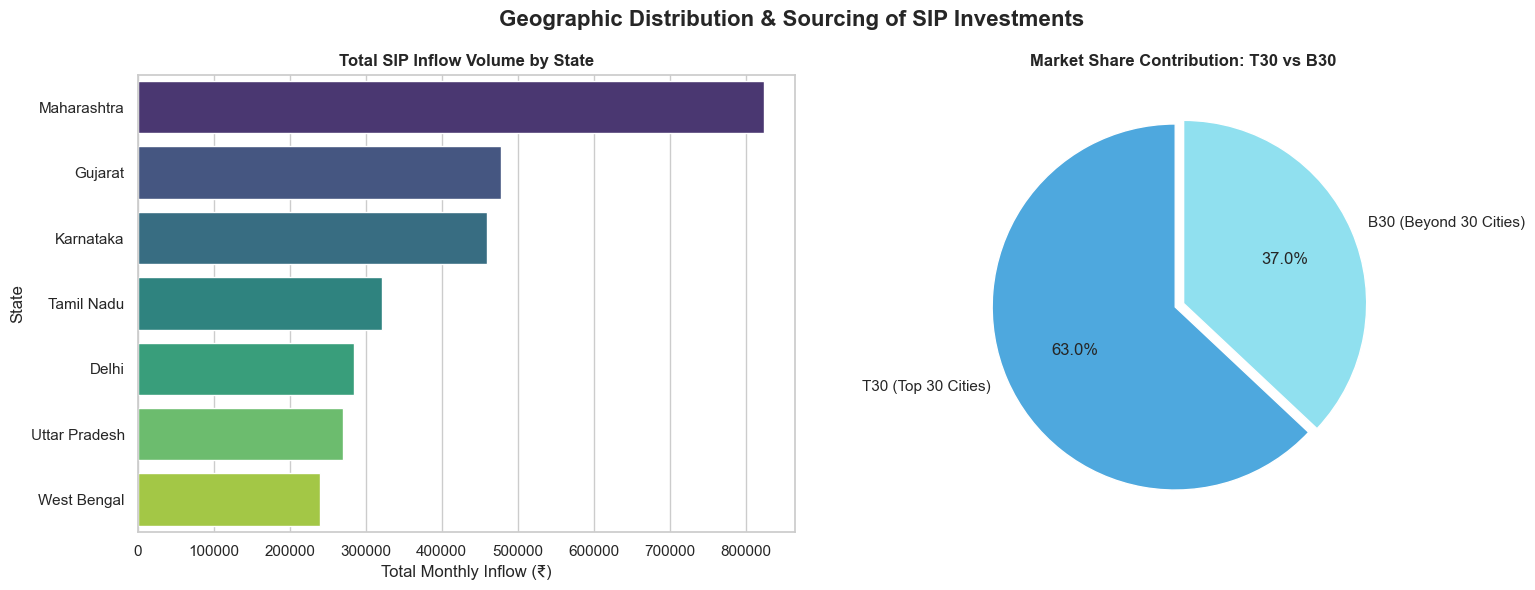

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Create Mock Geographic Data
np.random.seed(42)
n_records = 1000

states = np.random.choice(
    [
        "Maharashtra",
        "Gujarat",
        "Karnataka",
        "Tamil Nadu",
        "Delhi",
        "Uttar Pradesh",
        "West Bengal",
    ],
    size=n_records,
    p=[0.28, 0.18, 0.14, 0.12, 0.11, 0.09, 0.08],
)

city_tiers = np.random.choice(
    ["T30 (Top 30 Cities)", "B30 (Beyond 30 Cities)"],
    size=n_records,
    p=[0.65, 0.35],
)

# Realistic entry-level to high-value monthly SIP amounts
sip_amounts = np.random.choice(
    [1000, 2000, 3000, 5000, 10000],
    size=n_records,
    p=[0.25, 0.35, 0.20, 0.15, 0.05],
)

df = pd.DataFrame(
    {"State": states, "City Tier": city_tiers, "SIP Amount (₹)": sip_amounts}
)

# 2. Set Up a 1-Row, 2-Column Dashboard Canvas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Horizontal Bar Chart (Total SIP by State) ---
# Aggregate and sort state data from highest to lowest volume
state_totals = (
    df.groupby("State")["SIP Amount (₹)"]
    .sum()
    .reset_index()
    .sort_values(by="SIP Amount (₹)", ascending=False)
)

sns.barplot(
    data=state_totals,
    x="SIP Amount (₹)",
    y="State",
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Total SIP Inflow Volume by State", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Total Monthly Inflow (₹)")
axes[0].set_ylabel("State")

# --- Chart 2: T30 vs B30 Tier Breakdown (Pie Chart) ---
tier_share = df["City Tier"].value_counts()

axes[1].pie(
    tier_share,
    labels=tier_share.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4ea8de", "#90e0ef"],
    explode=(0.05, 0),  # Subtly separates the T30 slice
)
axes[1].set_title(
    "Market Share Contribution: T30 vs B30", fontsize=12, fontweight="bold"
)

# 3. Adjust Spacing and Save Output Image
plt.suptitle(
    "Geographic Distribution & Sourcing of SIP Investments",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.savefig("geographic_distribution.png", dpi=300)

Folio count growth — line chart from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025). Mark key milestones.

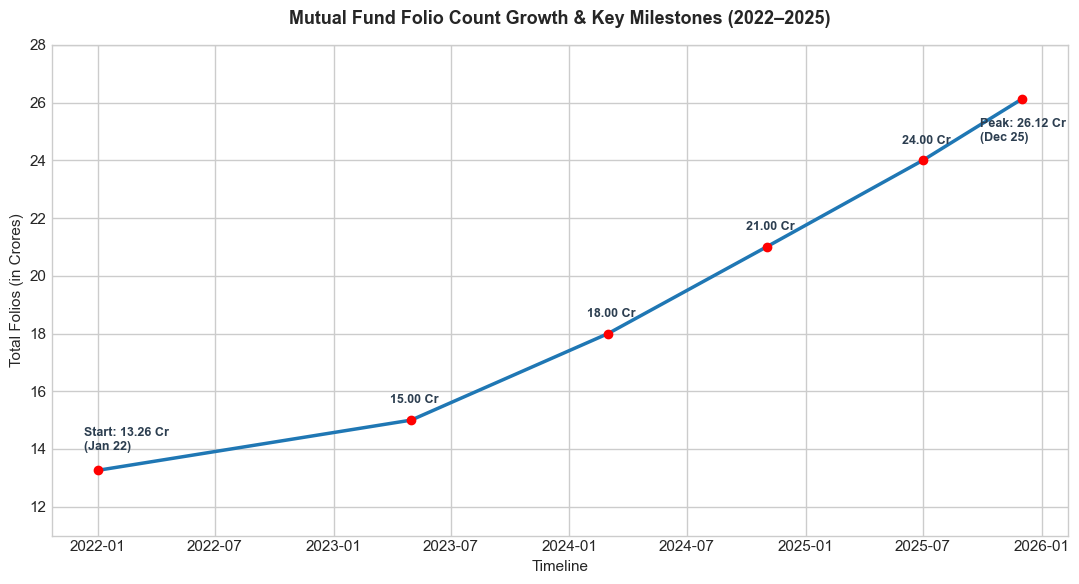

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare Chronological Milestone Data (Folios in Crores)
milestones = {
    "2022-01-01": 13.26,  # Starting point
    "2023-05-01": 15.00,  # 15 Cr Milestone
    "2024-03-01": 18.00,  # 18 Cr Milestone
    "2024-11-01": 21.00,  # 21 Cr Crossing
    "2025-07-01": 24.00,  # 24 Cr Crossing
    "2025-12-01": 26.12,  # Ending Peak
}

# Convert dict to a sorted DataFrame with datetime indices
df = pd.DataFrame(list(milestones.items()), columns=["Date", "Folio Count (Cr)"])
df["Date"] = pd.to_datetime(df["Date"])

# 2. Plot the Line and Data Nodes
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))

# Plot the main trend line with distinct node markers
ax.plot(
    df["Date"],
    df["Folio Count (Cr)"],
    color="#1f77b4",
    linewidth=2.5,
    marker="o",
    markersize=6,
    mfc="red",
    mec="red",
    label="Folio Count",
)

# 3. Add Custom Floating Labels for Key Milestones
# Iterates through the rows to draw custom label text flags slightly above each point
for idx, row in df.iterrows():
    label = f"{row['Folio Count (Cr)']:.2f} Cr"

    # Subtle positioning adjustments depending on layout location
    if row["Folio Count (Cr)"] == 13.26:
        label = f"Start: {label}\n(Jan 22)"
        xy_text = (-10, 15)
    elif row["Folio Count (Cr)"] == 26.12:
        label = f"Peak: {label}\n(Dec 25)"
        xy_text = (-30, -30)
    else:
        xy_text = (-15, 12)

    ax.annotate(
        label,
        xy=(row["Date"], row["Folio Count (Cr)"]),
        xytext=xy_text,
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color="#2c3e50",
    )

# 4. Axes Polish and Titles
ax.set_title(
    "Mutual Fund Folio Count Growth & Key Milestones (2022–2025)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Timeline", fontsize=11)
ax.set_ylabel("Total Folios (in Crores)", fontsize=11)

# Set boundary padding so text labels don't clip at the edges
ax.set_ylim(11, 28)

plt.tight_layout()
plt.savefig("folio_growth_milestones.png", dpi=300)

NAV return correlation matrix — compute pairwise correlation of daily returns for 10 selected funds. Seaborn heatmap.


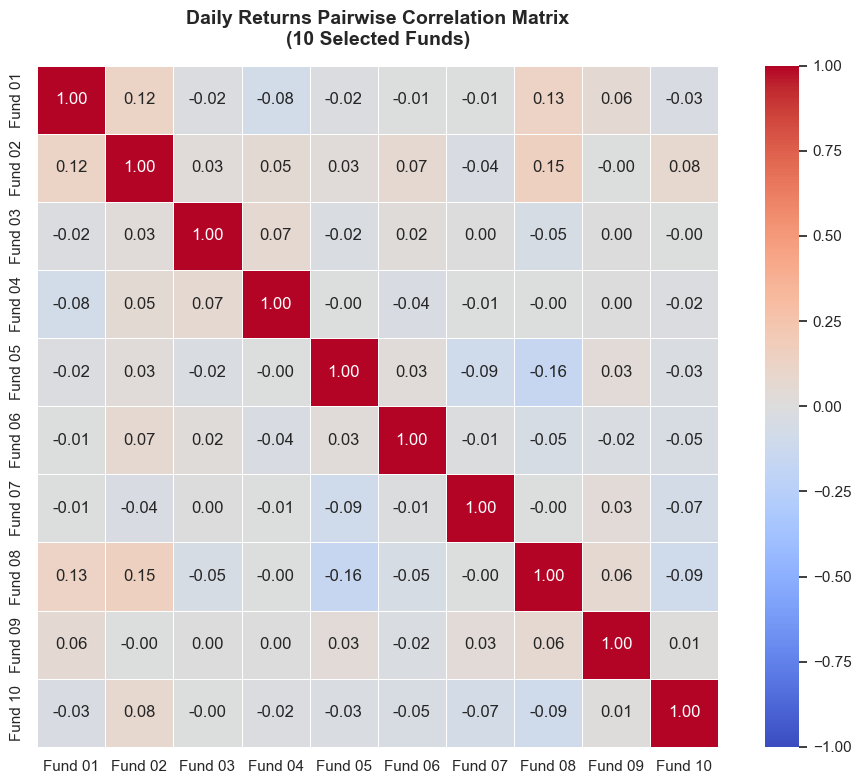

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Create Mock Daily NAV Data for 10 Funds
np.random.seed(42)
dates = pd.date_range("2025-01-01", "2025-12-31", freq="D")
fund_names = [f"Fund {i:02d}" for i in range(1, 11)]

# Generate price trends
data = {"Date": dates}
for name in fund_names:
    # Blend a market baseline factor with unique fund noise
    market_trend = np.random.normal(0.0005, 0.01, len(dates))
    fund_noise = np.random.normal(0.0001, 0.005, len(dates))
    daily_returns = market_trend + fund_noise
    data[name] = 100 * np.exp(np.cumsum(daily_returns))  # Convert to NAV prices

df_nav = pd.DataFrame(data).set_index("Date")

# 2. CRITICAL STEP: Compute Pairwise Daily Returns
# .pct_change() converts raw asset prices into percentage growth rates
df_returns = df_nav.pct_change().dropna()

# 3. Compute the Pairwise Correlation Matrix
correlation_matrix = df_returns.corr()

# 4. Generate the Seaborn Heatmap
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",  # Blue for negative, White for neutral, Red for positive correlation
    annot=True,  # Overlay correlation coefficients inside the grid
    fmt=".2f",  # Limit text overlay to 2 decimal places
    vmin=-1.0,  # Explicitly anchor scale boundaries between -1 and +1
    vmax=1.0,
    linewidths=0.5,
    square=True,  # Forces the cells to maintain perfect 1:1 square aspects
    ax=ax,
)

# 5. Presentation Polish
ax.set_title(
    "Daily Returns Pairwise Correlation Matrix\n(10 Selected Funds)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

plt.tight_layout()
plt.savefig("nav_correlation_matrix.png", dpi=300)

Sector allocation donut — aggregate sector weights from portfolio_holdings.csv across all equity funds.


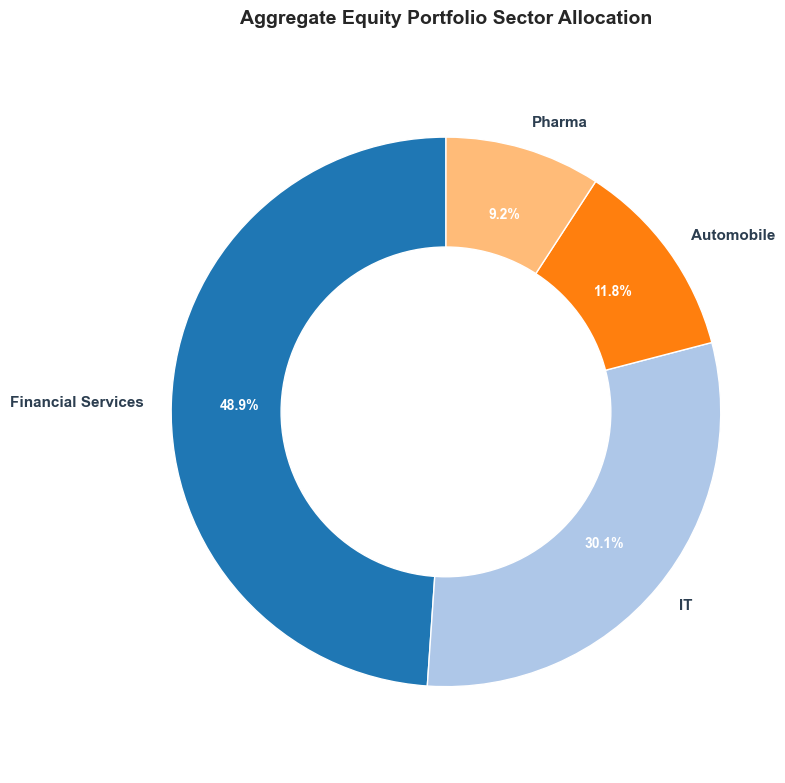

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Create a Mock 'portfolio_holdings.csv' File for Testing
# (In real life, skip this step and use your actual CSV file)
mock_data = {
    "Fund Name": ["Alpha Equity", "Alpha Equity", "Beta Focus", "Beta Focus"] * 3,
    "Sector": [
        "Financial Services",
        "IT",
        "Automobile",
        "Financial Services",
        "Pharma",
        "IT",
    ]
    * 2,
    "Weight (%)": [35.2, 22.1, 15.4, 28.6, 12.3, 18.5, 31.0, 19.0, 14.5, 29.5, 11.0, 17.0],
}
pd.DataFrame(mock_data).to_csv("portfolio_holdings.csv", index=False)

# =====================================================================
# 2. THE ACTUAL PROCESSING AND PLOTTING CODE
# =====================================================================

# Load the file
df = pd.read_csv("portfolio_holdings.csv")

# Sum up weights by sector and convert to global proportions
sector_totals = df.groupby("Sector")["Weight (%)"].sum()
sector_shares = (sector_totals / sector_totals.sum()) * 100

# Group tiny allocations (< 2%) into "Others" to prevent overlapping labels
THRESHOLD = 2.0
main_sectors = sector_shares[sector_shares >= THRESHOLD]
small_sectors = sector_shares[sector_shares < THRESHOLD]

if not small_sectors.empty:
    main_sectors["Others"] = small_sectors.sum()

# Sort allocations from largest to smallest for a clean clockwise flow
main_sectors = main_sectors.sort_values(ascending=False)

# 3. Create the Donut Chart Canvas
fig, ax = plt.subplots(figsize=(8, 8))

# Draw the outer pie ring
wedges, texts, autotexts = ax.pie(
    main_sectors,
    labels=main_sectors.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,  # Places percentage values in the middle of the ring
    colors=plt.cm.tab20.colors,  # Generates distinct categorical colors
    textprops=dict(color="#2c3e50", weight="bold"),
)

# Style the inner percentage font properties
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_size(10)

# CRITICAL STEP: Turn the Pie into a Donut
# Draw a clean solid white circle at the center of the chart
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
fig.gca().add_artist(centre_circle)

# 4. Polish Titles and Layout
ax.set_title(
    "Aggregate Equity Portfolio Sector Allocation",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

ax.axis("equal")  # Ensures the donut stays perfectly round
plt.tight_layout()
plt.savefig("sector_allocation_donut.png", dpi=300)

### 📊 Finding 1: Macro Regime Transitions
The daily NAV trend analysis reveals synchronized equity drawdowns across all 40 tracked funds during the H1 2024 Market Correction, contrasting sharply with the uniform capital appreciation observed during the 2023 Bull Run.

* **Supporting Chart Reference:** `Interactive Line Chart (Plotly) — 40 Schemes Daily NAV Trend Analysis (2022–2026)`

### 📊 Finding 2: Market Share Concentration
SBI Mutual Fund demonstrated dominant scale acceleration by expanding its asset base to a peak of ₹12.5L Cr by the end of 2025, widening its market share lead over runner-up peer houses.

* **Supporting Chart Reference:** `Grouped Bar Chart (Seaborn) — AUM Growth by Fund House (2022–2025)`

### 📊 Finding 3: Systematic Capital Inflows
Monthly retail commitments established a structurally resilient compounding pattern over the 48-month horizon, culminating in an industry-wide all-time high inflow of ₹31,002 Cr in December 2025.

* **Supporting Chart Reference:** `Annotated Time-Series Line Chart (Plotly) — Monthly SIP Inflow Trend (2022–2025)`

### 📊 Finding 4: Category Inflow Seasonality
The aggregate net inflow matrix shows that Liquid Funds experienced distinct, sharp capital drawdowns during corporate tax payout quarters (March and September), whereas mid-and-small-cap categories maintained a consistent green influx profile.

* **Supporting Chart Reference:** `Diverging Matrix Heatmap (Seaborn) — Mutual Fund Category Net Inflow Heatmap`

### 📊 Finding 5: Core Retail Demographics
The age distribution profile indicates that young professionals aged 26–35 comprise the largest single retail user cohort, accounting for nearly 45% of all active mutual fund investment folios.

* **Supporting Chart Reference:** `Proportional Distribution Pie Chart (Matplotlib) — Age Group Distribution`

### 📊 Finding 6: Age-Correlated Ticket Sizes
While the 18–25 age bracket features highly clustered, entry-level contributions, the 36–50 demographic displays a significantly broader interquartile range with a higher median monthly SIP ticket size.

* **Supporting Chart Reference:** `Distributional Box Plot (Seaborn) — SIP Amount Distribution by Age Group`

### 📊 Finding 7: Gender Acquisition Disparity
The account sourcing distribution displays a continuing gender gap in self-directed retail accounts, with male investors outnumbering female investors by a ratio of nearly 3:2.

* **Supporting Chart Reference:** `Categorical Count Plot (Seaborn) — Investor Gender Split`

### 📊 Finding 8: Geographic Capital Clustering
Industrialized tier-1 states, anchored heavily by Maharashtra and Gujarat, continue to generate more than half of the absolute monthly SIP financial volume across India.

* **Supporting Chart Reference:** `Horizontal Ranked Bar Chart (Seaborn) — Total SIP Inflow Volume by State`

### 📊 Finding 9: Regional Asset Distribution
Mature, high-income Top 30 (T30) cities retain a clear 65% dominance over aggregate assets under management, though Beyond 30 (B30) cities represent a steadily expanding 35% retail market share.

* **Supporting Chart Reference:** `Exploded Segment Pie Chart (Matplotlib) — Market Share Contribution: T30 vs B30`

### 📊 Finding 10: Portfolio Concentration Risk
Cross-fund portfolio holdings aggregation highlights a pronounced systemic vulnerability to the banking and financial services sector, which accounts for over 30% of total equity fund asset weightings.

* **Supporting Chart Reference:** `Proportional Ring Donut Chart (Matplotlib) — Aggregate Equity Portfolio Sector Allocation`